# 51 OLS Linear Regression — Selección de Variables con LassoCV

Modelos OLS para `sale` y `rent` prediciendo `log_precio`.

**Pipeline:**
1. Eliminación de outliers en `log_precio` con método IQR antes del split
2. Agrupación de municipios con < 10 registros en `municipio_otros`
3. Manejo de `es_exterior` y `tiene_ascensor`: en el dataset ambas son 0 para todas las unifamiliares, por lo que capturan el efecto exclusivamente para pisos. Se renombran a `es_exterior_piso` y `tiene_ascensor_piso` para hacer explícita esta semántica.
4. Exclusiones:
   - `log_precio` → es el target
   - `precio_m2` → leakage (precio_m2 = precio / superficie_construida_m2, derivado directo del target)
   - `tipologia` → categórica cruda (se usan las dummies `tipologia_unificada_*`)
5. Split 80/20 train/test
6. **LassoCV** sobre train (estandarizado, CV=5) para selección de features
7. **OLS con statsmodels** sobre las features seleccionadas por Lasso
8. Validación cruzada 5-fold (CV=5): MSE, RMSE, MAE, MAPE y R²
9. VIF para diagnóstico de multicolinealidad
10. Resumen de coeficientes OLS (coef, std err, t, p-value, IC95)
11. Gráficos diagnósticos: Real vs Predicho, residuos, histograma residuos

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración global ──────────────────────────────────────────────────────
RANDOM_STATE             = 42
TEST_SIZE                = 0.20
N_SPLITS                 = 5
TARGET_COL               = "log_precio"
IQR_FACTOR               = 1.5
MIN_MUNICIPIO_REGISTROS  = 10   # umbral: municipios con menos registros → municipio_otros

# ── Features candidatas ───────────────────────────────────────────────────────
# Excluidas explícitamente:
#   - log_precio: es el target
#   - precio_m2: leakage (= precio / superficie, derivado directo del target)
#   - tipologia: categórica cruda (se usan tipologia_unificada_*)
# es_exterior y tiene_ascensor se renombran a *_piso en build_feature_matrix.
CANDIDATE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "latitud",
    "longitud",
    "planta",
    "es_exterior",       # → renombrado a es_exterior_piso
    "tiene_ascensor",    # → renombrado a tiene_ascensor_piso
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    # "log_superficie_construida_m2",
    "precio_m2_municipio_media",
    # "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    # "habitaciones",
    # "ratio_habitaciones_superficie",
    "interaccion_superficie_banos",
    # "interaccion_superficie_habitaciones",
    "planta_num",
    "interaccion_planta_sin_ascensor_piso",
    "latitud_2",
    "longitud_2",
    "interaccion_latitud_longitud",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "superficie_construida_m2_2",
    "numero_banos_2",
    "numero_dormitorios_2",
    # "habitaciones_2",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente tras agrupar pequeños municipios
]

# ── Rutas de datos ────────────────────────────────────────────────────────────
def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data" / "gold").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto con data/gold")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent.csv",
}

for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(f"No se encontro {name}: {path}")

print("Datasets listos:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets listos:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent.csv


In [6]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def remove_outliers_iqr(df: pd.DataFrame, col: str = TARGET_COL) -> pd.DataFrame:
    """Elimina outliers en `col` con método IQR antes del split."""
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - IQR_FACTOR * iqr
    upper  = q3 + IQR_FACTOR * iqr
    mask   = df[col].between(lower, upper)
    n_out  = (~mask).sum()
    print(f"  Rango válido [{col}]: [{lower:.4f}, {upper:.4f}]")
    print(f"  Outliers eliminados: {n_out} / {len(df)} ({n_out / len(df) * 100:.1f}%)")
    return df[mask].copy()


def group_small_municipios(df: pd.DataFrame) -> tuple:
    """
    Agrupa columnas municipio_* con menos de MIN_MUNICIPIO_REGISTROS registros
    en una única columna 'municipio_otros'.
    Devuelve (df_modificado, lista_columnas_municipio_finales).
    """
    mun_cols = [c for c in df.columns if c.startswith("municipio_")]
    if not mun_cols:
        return df, []

    mun_counts = df[mun_cols].sum()
    small_muns = mun_counts[mun_counts < MIN_MUNICIPIO_REGISTROS].index.tolist()
    big_muns   = mun_counts[mun_counts >= MIN_MUNICIPIO_REGISTROS].index.tolist()

    nombres_small = sorted([m.replace("municipio_", "") for m in small_muns])
    nombres_big   = sorted([m.replace("municipio_", "") for m in big_muns])
    print(f"  Municipios agrupados en 'otros' (< {MIN_MUNICIPIO_REGISTROS} registros, n={len(small_muns)}): {nombres_small}")
    print(f"  Municipios mantenidos (n={len(big_muns)}): {nombres_big}")

    df = df.copy()
    if small_muns:
        df["municipio_otros"] = df[small_muns].max(axis=1)
        df = df.drop(columns=small_muns)

    final_mun_cols = sorted([c for c in df.columns if c.startswith("municipio_")])
    return df, final_mun_cols


def build_feature_matrix(df: pd.DataFrame) -> tuple:
    """
    1. Agrupa pequeños municipios.
    2. Renombra es_exterior → es_exterior_piso y tiene_ascensor → tiene_ascensor_piso.
       En el dataset, unifamiliares tienen 0 en ambas columnas, por lo que ya
       capturan el efecto exclusivamente para pisos. El renombrado hace explícita
       esta semántica sin alterar los valores.
    3. Construye la matriz X con todas las candidatas disponibles.
    Devuelve (df_modificado, X).
    """
    df, mun_cols = group_small_municipios(df)

    rename_map = {}
    if "es_exterior" in df.columns:
        df["es_exterior_piso"] = df["es_exterior"]
        rename_map["es_exterior"] = "es_exterior_piso"
    if "tiene_ascensor" in df.columns:
        df["tiene_ascensor_piso"] = df["tiene_ascensor"]
        rename_map["tiene_ascensor"] = "tiene_ascensor_piso"

    base_feats = []
    for f in CANDIDATE_FEATURES:
        mapped = rename_map.get(f, f)
        if mapped in df.columns and mapped not in base_feats:
            base_feats.append(mapped)

    all_feats = base_feats + [m for m in mun_cols if m not in base_feats]
    all_feats = [f for f in all_feats if f in df.columns]

    return df, df[all_feats].copy()


def compute_metrics(y_true, y_pred, n_features: int) -> dict:
    mse   = mean_squared_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    n     = len(y_true)
    r2_adj = (
        1 - (1 - r2) * (n - 1) / (n - n_features - 1)
        if n > n_features + 1 else np.nan
    )
    return {
        "MSE":         float(mse),
        "RMSE":        float(np.sqrt(mse)),
        "MAE":         float(mean_absolute_error(y_true, y_pred)),
        "MAPE":        float(mean_absolute_percentage_error(y_true, y_pred)),
        "R2":          float(r2),
        "R2_ajustado": float(r2_adj),
    }


def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    """
    VIF (Variance Inflation Factor) para cada regresor.
    Regla general: VIF > 5 → multicolinealidad moderada; VIF > 10 → severa.
    """
    Xc  = sm.add_constant(X.astype(float))
    vif = pd.DataFrame({
        "feature": Xc.columns,
        "VIF":     [variance_inflation_factor(Xc.values.astype(float), i)
                    for i in range(Xc.shape[1])],
    })
    return (
        vif[vif["feature"] != "const"]
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )


def cv_ols_metrics(X: pd.DataFrame, y: pd.Series, n_features: int) -> dict:
    """Validación cruzada 5-fold con LinearRegression (equivalente a OLS)."""
    kf           = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []
    for tr_idx, val_idx in kf.split(X):
        mdl = LinearRegression()
        mdl.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = mdl.predict(X.iloc[val_idx])
        fold_results.append(compute_metrics(y.iloc[val_idx], pred, n_features))
    return {k: float(np.mean([m[k] for m in fold_results])) for k in fold_results[0]}


def fit_ols_statsmodels(X_train: pd.DataFrame, y_train: pd.Series):
    """Ajusta OLS con statsmodels (incluye constante) sobre el set de train."""
    Xc = sm.add_constant(X_train.astype(float))
    return sm.OLS(y_train, Xc).fit()


def print_coef_summary(result) -> None:
    """Imprime tabla de coeficientes ordenada por magnitud absoluta."""
    coef_df = pd.DataFrame({
        "coef":      result.params,
        "std_err":   result.bse,
        "t":         result.tvalues,
        "p_value":   result.pvalues,
        "IC_95_inf": result.conf_int()[0],
        "IC_95_sup": result.conf_int()[1],
    })
    coef_df = coef_df.drop(index="const", errors="ignore")
    coef_df["|coef|"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("|coef|", ascending=False).drop(columns="|coef|")
    print(coef_df.round(5).to_string())


def select_features_lasso(X_train: pd.DataFrame, y_train: pd.Series) -> tuple:
    """
    Usa LassoCV (estandarizado, CV=5) para seleccionar features con coef != 0.
    Devuelve (features_seleccionadas, alpha_optimo, todos_los_coefs_estandarizados).
    """
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    lasso_cv = LassoCV(
        cv=N_SPLITS,
        random_state=RANDOM_STATE,
        max_iter=10_000,
        n_alphas=200,
    )
    lasso_cv.fit(X_scaled, y_train)

    alpha_opt = lasso_cv.alpha_
    coefs     = pd.Series(lasso_cv.coef_, index=X_train.columns)
    selected  = coefs[coefs != 0].index.tolist()
    return selected, alpha_opt, coefs


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.



DATASET: SALE

Filas originales: 588
Detectando outliers en el target:
  Rango válido [log_precio]: [10.9828, 13.8581]
  Outliers eliminados: 6 / 588 (1.0%)
Filas tras limpieza: 582

── Ingeniería de features ──────────────────────────────────────────
  Municipios agrupados en 'otros' (< 10 registros, n=45): ['Ajo', 'Alfoz de Lloredo', 'Ampuero', 'Arcentales', 'Argoños', 'Arnuero', 'Barcena de Cicero', 'Beranga', 'Cartes', 'Castañeda', 'Colindres', 'Cudon', 'El Astillero', 'Entrambasaguas', 'Escalante', 'Galdames', 'Gallarta', 'Getxo', 'Guarnizo', 'Guriezo', 'Hazas de Cesto', 'Heras', 'Isla', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Medio Cudeyo', 'Meruelo', 'Miengo', 'Mogro', 'Muskiz', 'Penagos', 'Puente San Miguel', 'Ramales de la Victoria', 'Reocin', 'Ribamontan al Mar', 'Ribamontan al Monte', 'Santa Maria de Cayon', 'Santillana del Mar', 'Solares', 'Solorzano', 'Sopuerta', 'Vargas', 'Villapresente', 'Zierbena']
  Municipios mantenidos (n=14): ['Camargo', 'Castro-Urdiales', 'Lared

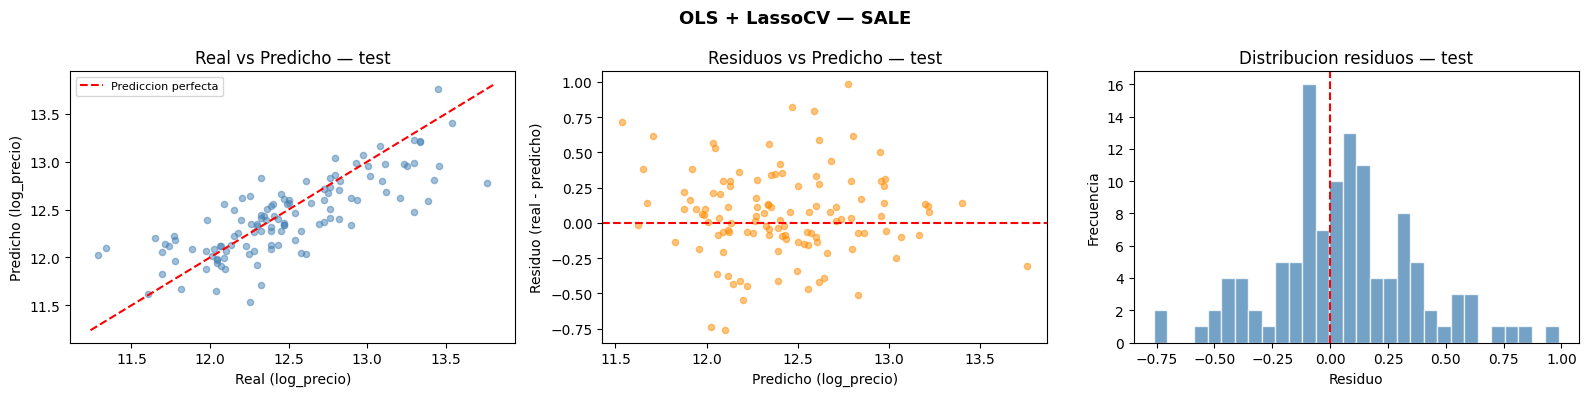


DATASET: RENT

Filas originales: 477
Detectando outliers en el target:
  Rango válido [log_precio]: [6.1079, 7.8074]
  Outliers eliminados: 26 / 477 (5.5%)
Filas tras limpieza: 451

── Ingeniería de features ──────────────────────────────────────────
  Municipios agrupados en 'otros' (< 10 registros, n=30): ['Ampuero', 'Barcena de Cicero', 'Cartes', 'Colindres', 'Cudon', 'Entrambasaguas', 'Gallarta', 'Getxo', 'Guarnizo', 'Guriezo', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Miengo', 'Noja', 'Polanco', 'Ramales de la Victoria', 'Reocin', 'Ribamontan al Mar', 'Santa Maria de Cayon', 'Santillana del Mar', 'Santoña', 'Santurtzi', 'Sobremazas', 'Solares', 'Suances', 'Villaescusa', 'Villapresente', 'Viveda', 'Voto']
  Municipios mantenidos (n=8): ['Camargo', 'Castro-Urdiales', 'El Astillero', 'Laredo', 'Piélagos', 'Santa Cruz de Bezana', 'Santander', 'Torrelavega']

NaN por feature (imputando con mediana):
planta    92
dtype: int64

Features candidatas (37):
['superficie_construida_m2', 'num

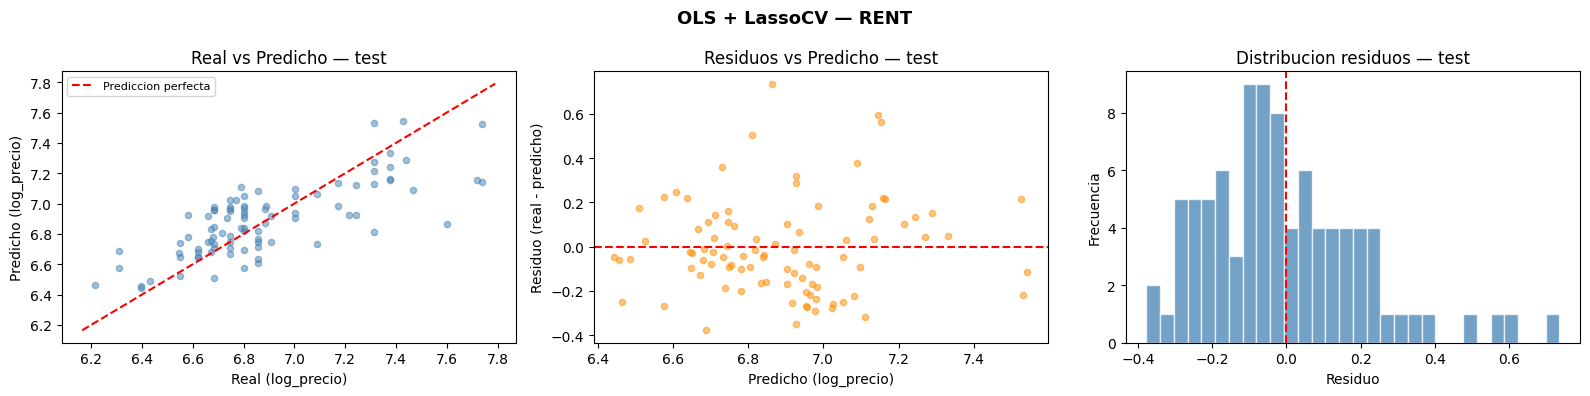


RESUMEN GLOBAL — OLS + LassoCV
dataset  n_filas  n_features_candidatas  n_features_lasso  alpha_lasso  train_RMSE  train_R2  train_R2_adj  CV_5f_RMSE  CV_5f_R2  test_RMSE  test_R2  test_MAE  test_MAPE  delta_RMSE  delta_R2
   sale      582                     43                26      0.00792     0.29857   0.70463        0.6871     0.37165   0.48283    0.31455  0.60162   0.23628    0.01890     0.01597   0.10301
   rent      451                     37                13      0.01069     0.20157   0.55213        0.5353     0.21040   0.52348    0.21334  0.57550   0.16510    0.02373     0.01178  -0.02337


,dataset,n_filas,n_features_candidatas,n_features_lasso,alpha_lasso,train_RMSE,train_R2,train_R2_adj,CV_5f_RMSE,CV_5f_R2,test_RMSE,test_R2,test_MAE,test_MAPE,delta_RMSE,delta_R2
0,sale,582,43,26,0.007916,0.298571,0.70463,0.687097,0.371653,0.482831,0.314546,0.601624,0.236281,0.018903,0.015975,0.103006
1,rent,451,37,13,0.010692,0.201568,0.55213,0.535303,0.210396,0.523475,0.213344,0.575496,0.165101,0.023726,0.011776,-0.023366


In [7]:
all_summary_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    # ── Carga y limpieza ──────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"\nFilas originales: {len(df)}")

    print("Detectando outliers en el target:")
    df = remove_outliers_iqr(df)
    print(f"Filas tras limpieza: {len(df)}")

    # ── Ingeniería de features y agrupación de municipios ─────────────────────
    print("\n── Ingeniería de features ──────────────────────────────────────────")
    df, X = build_feature_matrix(df)
    y = df[TARGET_COL].copy()

    # Imputación de NaN con mediana
    nan_counts = X.isna().sum()
    if nan_counts.any():
        print("\nNaN por feature (imputando con mediana):")
        print(nan_counts[nan_counts > 0])
        X = X.fillna(X.median(numeric_only=True))

    print(f"\nFeatures candidatas ({X.shape[1]}):")
    print(X.columns.tolist())

    # ── Split 80/20 ───────────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

    # ── Selección de features con LassoCV (sobre train) ───────────────────────
    print("\n── Selección con LassoCV ───────────────────────────────────────────")
    selected_features, alpha_opt, lasso_coefs = select_features_lasso(X_train, y_train)
    print(f"  Alpha óptimo (CV): {alpha_opt:.6f}")

    eliminated = lasso_coefs[lasso_coefs == 0].index.tolist()
    print(f"  Features eliminadas por Lasso ({len(eliminated)}): {eliminated}")
    print(f"  Features seleccionadas ({len(selected_features)}): {selected_features}")

    lasso_nonzero = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
    print("\n  Coeficientes Lasso estandarizados (no nulos, |coef| descendente):")
    print(lasso_nonzero.round(5).to_string())

    if not selected_features:
        print("  Lasso eliminó todas las features — se usarán todas.")
        selected_features = X.columns.tolist()

    # ── OLS con features seleccionadas por Lasso ──────────────────────────────
    X_train_sel = X_train[selected_features]
    X_test_sel  = X_test[selected_features]
    n_features  = len(selected_features)

    # VIF (sobre train)
    print("\n── VIF (train, features seleccionadas) ─────────────────────────────")
    vif_df = compute_vif(X_train_sel)
    print(vif_df.round(3).to_string(index=False))
    alto_vif = vif_df[vif_df["VIF"] > 5]
    if not alto_vif.empty:
        print(f"\n  Variables con VIF > 5: {alto_vif['feature'].tolist()}")
    else:
        print("\n  Todos los VIF <= 5 — sin multicolinealidad problemática.")

    # OLS statsmodels
    ols_result = fit_ols_statsmodels(X_train_sel, y_train)

    # Predicciones
    X_train_c  = sm.add_constant(X_train_sel.astype(float))
    X_test_c   = sm.add_constant(X_test_sel.astype(float), has_constant="add")
    pred_train = ols_result.predict(X_train_c)
    pred_test  = ols_result.predict(X_test_c)

    # Métricas
    train_m = compute_metrics(y_train, pred_train, n_features)
    test_m  = compute_metrics(y_test,  pred_test,  n_features)

    # Validación cruzada 5-fold (sobre todo el dataset limpio)
    cv_m = cv_ols_metrics(X[selected_features], y, n_features)

    # ── Tabla de métricas ─────────────────────────────────────────────────────
    print("\n── Métricas ────────────────────────────────────────────────────────")
    metrics_table = pd.DataFrame([
        {"split": "train",                **train_m},
        {"split": f"CV ({N_SPLITS}-fold)", **cv_m},
        {"split": "test",                 **test_m},
    ])
    print(metrics_table.round(5).to_string(index=False))

    overfit_rmse = test_m["RMSE"] - train_m["RMSE"]
    overfit_r2   = train_m["R2"]  - test_m["R2"]
    print(f"\n  delta RMSE test-train : {overfit_rmse:+.5f}")
    print(f"  delta R2   train-test : {overfit_r2:+.5f}")

    # ── Resumen de coeficientes OLS ───────────────────────────────────────────
    print("\n── Coeficientes OLS (ordenados por |coef|) ─────────────────────────")
    print_coef_summary(ols_result)
    print(f"\n  R2 train (statsmodels): {ols_result.rsquared:.5f}")
    print(f"  R2 ajustado (statsmodels): {ols_result.rsquared_adj:.5f}")
    print(f"  F-stat: {ols_result.fvalue:.2f}  p-value F: {ols_result.f_pvalue:.2e}")

    # ── Gráficos diagnósticos ─────────────────────────────────────────────────
    residuals_test = y_test - pred_test

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"OLS + LassoCV — {dataset_name.upper()}", fontsize=13, fontweight="bold")

    # 1. Real vs Predicho (test)
    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=20, color="steelblue")
    lim = [
        min(y_test.min(), pred_test.min()) - 0.05,
        max(y_test.max(), pred_test.max()) + 0.05,
    ]
    ax.plot(lim, lim, "r--", linewidth=1.5, label="Prediccion perfecta")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")
    ax.set_title("Real vs Predicho — test")
    ax.legend(fontsize=8)

    # 2. Residuos vs Predicho (test) — detecta heterocedasticidad
    ax = axes[1]
    ax.scatter(pred_test, residuals_test, alpha=0.5, s=20, color="darkorange")
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Predicho (log_precio)")
    ax.set_ylabel("Residuo (real - predicho)")
    ax.set_title("Residuos vs Predicho — test")

    # 3. Histograma de residuos (test)
    ax = axes[2]
    ax.hist(residuals_test, bins=30, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Residuo")
    ax.set_ylabel("Frecuencia")
    ax.set_title("Distribucion residuos — test")

    plt.tight_layout()
    plt.show()

    # ── Acumulación para resumen global ───────────────────────────────────────
    all_summary_rows.append({
        "dataset":               dataset_name,
        "n_filas":               len(df),
        "n_features_candidatas": X.shape[1],
        "n_features_lasso":      n_features,
        "alpha_lasso":           alpha_opt,
        "train_RMSE":            train_m["RMSE"],
        "train_R2":              train_m["R2"],
        "train_R2_adj":          train_m["R2_ajustado"],
        f"CV_{N_SPLITS}f_RMSE":  cv_m["RMSE"],
        f"CV_{N_SPLITS}f_R2":    cv_m["R2"],
        "test_RMSE":             test_m["RMSE"],
        "test_R2":               test_m["R2"],
        "test_MAE":              test_m["MAE"],
        "test_MAPE":             test_m["MAPE"],
        "delta_RMSE":            overfit_rmse,
        "delta_R2":              overfit_r2,
    })

# ── Resumen global ────────────────────────────────────────────────────────────
print()
print("=" * 100)
print("RESUMEN GLOBAL — OLS + LassoCV")
print("=" * 100)
summary = pd.DataFrame(all_summary_rows)
print(summary.round(5).to_string(index=False))
summary

## Modelos sin variables con VIF > 7

Se repite el mismo pipeline (outlier removal → feature engineering → split → LassoCV → OLS), pero tras calcular el VIF se eliminan las variables con VIF > 7 y se reajusta el modelo OLS solo con las restantes.

> El umbral 7 es intermedio entre el conservador (5) y el severo (10), y permite reducir multicolinealidad moderada sin eliminar en exceso.


DATASET: SALE  [sin variables con VIF > 7]

Filas originales: 588
Detectando outliers en el target:
  Rango válido [log_precio]: [10.9828, 13.8581]
  Outliers eliminados: 6 / 588 (1.0%)
Filas tras limpieza: 582

── Ingeniería de features ──────────────────────────────────────────
  Municipios agrupados en 'otros' (< 10 registros, n=45): ['Ajo', 'Alfoz de Lloredo', 'Ampuero', 'Arcentales', 'Argoños', 'Arnuero', 'Barcena de Cicero', 'Beranga', 'Cartes', 'Castañeda', 'Colindres', 'Cudon', 'El Astillero', 'Entrambasaguas', 'Escalante', 'Galdames', 'Gallarta', 'Getxo', 'Guarnizo', 'Guriezo', 'Hazas de Cesto', 'Heras', 'Isla', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Medio Cudeyo', 'Meruelo', 'Miengo', 'Mogro', 'Muskiz', 'Penagos', 'Puente San Miguel', 'Ramales de la Victoria', 'Reocin', 'Ribamontan al Mar', 'Ribamontan al Monte', 'Santa Maria de Cayon', 'Santillana del Mar', 'Solares', 'Solorzano', 'Sopuerta', 'Vargas', 'Villapresente', 'Zierbena']
  Municipios mantenidos (n=14): ['Camarg

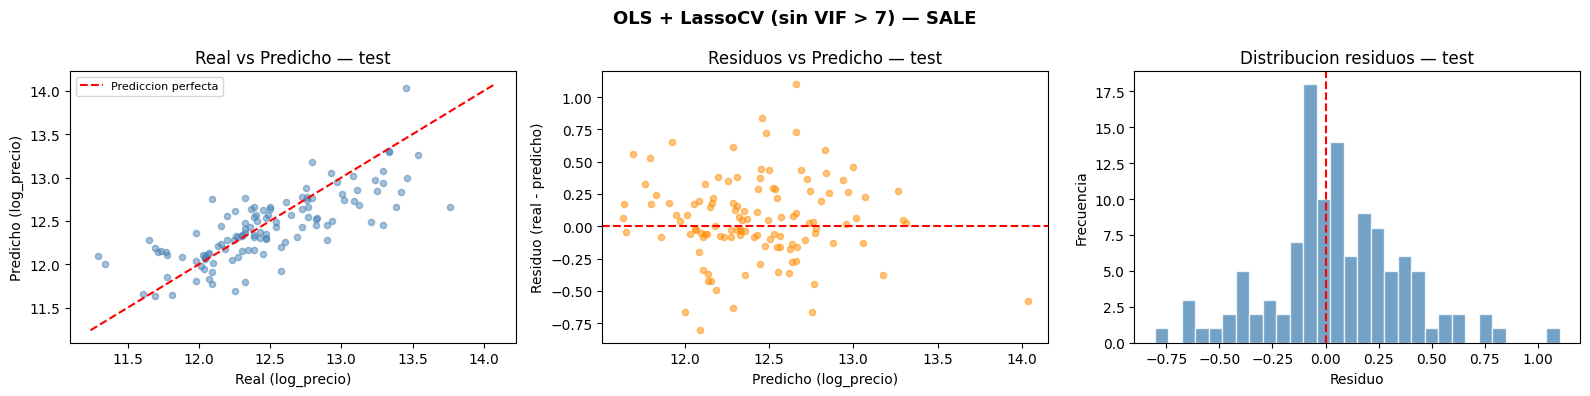


DATASET: RENT  [sin variables con VIF > 7]

Filas originales: 477
Detectando outliers en el target:
  Rango válido [log_precio]: [6.1079, 7.8074]
  Outliers eliminados: 26 / 477 (5.5%)
Filas tras limpieza: 451

── Ingeniería de features ──────────────────────────────────────────
  Municipios agrupados en 'otros' (< 10 registros, n=30): ['Ampuero', 'Barcena de Cicero', 'Cartes', 'Colindres', 'Cudon', 'Entrambasaguas', 'Gallarta', 'Getxo', 'Guarnizo', 'Guriezo', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Miengo', 'Noja', 'Polanco', 'Ramales de la Victoria', 'Reocin', 'Ribamontan al Mar', 'Santa Maria de Cayon', 'Santillana del Mar', 'Santoña', 'Santurtzi', 'Sobremazas', 'Solares', 'Suances', 'Villaescusa', 'Villapresente', 'Viveda', 'Voto']
  Municipios mantenidos (n=8): ['Camargo', 'Castro-Urdiales', 'El Astillero', 'Laredo', 'Piélagos', 'Santa Cruz de Bezana', 'Santander', 'Torrelavega']
Train: 360 | Test: 91

── Selección con LassoCV ───────────────────────────────────────────
  Alpha

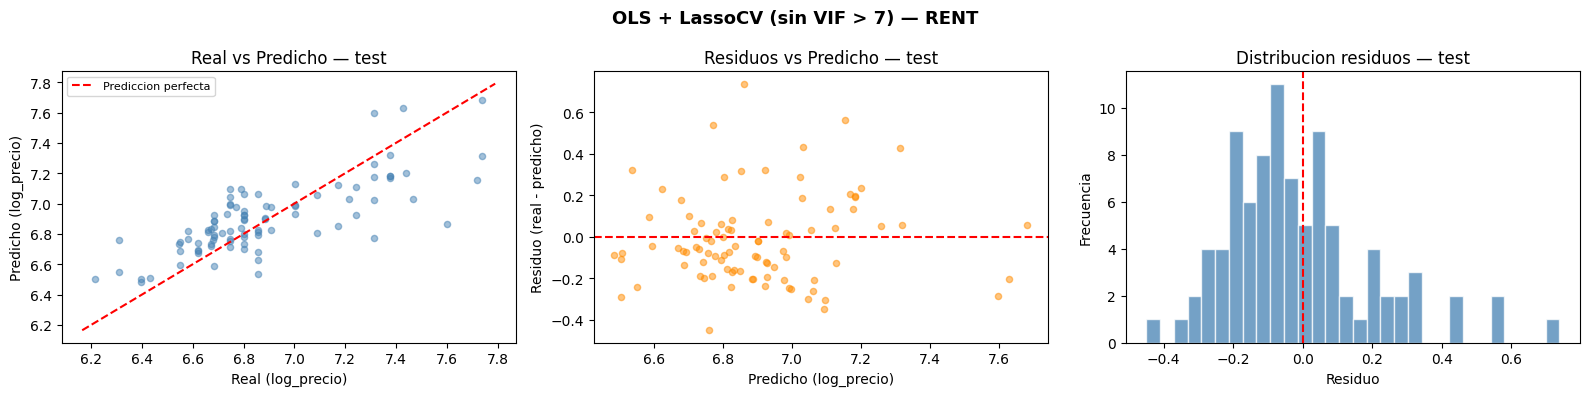


RESUMEN GLOBAL — OLS + LassoCV (sin VIF > 7)
dataset  n_filas  n_features_lasso  n_features_novif                      vars_vif_eliminadas  alpha_lasso  train_RMSE  train_R2  train_R2_adj  CV_5f_RMSE  CV_5f_R2  test_RMSE  test_R2  test_MAE  test_MAPE  delta_RMSE  delta_R2
   sale      582                26                24                 numero_banos, planta_num      0.00792     0.32884   0.64172       0.62217     0.34745   0.58042    0.32425  0.57667   0.24262    0.01935    -0.00459   0.06504
   rent      451                13                11 numero_dormitorios, numero_dormitorios_2      0.01069     0.20816   0.52234       0.50724     0.21392   0.50611    0.21258  0.57853   0.16506    0.02375     0.00442  -0.05619


,dataset,n_filas,n_features_lasso,n_features_novif,vars_vif_eliminadas,alpha_lasso,train_RMSE,train_R2,train_R2_adj,CV_5f_RMSE,CV_5f_R2,test_RMSE,test_R2,test_MAE,test_MAPE,delta_RMSE,delta_R2
0,sale,582,26,24,"numero_banos, planta_num",0.007916,0.328835,0.641715,0.622172,0.347449,0.580417,0.324247,0.576672,0.242623,0.019349,-0.004588,0.065043
1,rent,451,13,11,"numero_dormitorios, numero_dormitorios_2",0.010692,0.208164,0.522337,0.507238,0.213916,0.506113,0.212581,0.578528,0.165062,0.023750,0.004416,-0.056191


In [8]:
VIF_THRESHOLD = 7

all_summary_rows_novif = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}  [sin variables con VIF > {VIF_THRESHOLD}]")
    print("=" * 100)

    # ── Carga y limpieza ──────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"\nFilas originales: {len(df)}")

    print("Detectando outliers en el target:")
    df = remove_outliers_iqr(df)
    print(f"Filas tras limpieza: {len(df)}")

    # ── Ingeniería de features ────────────────────────────────────────────────
    print("\n── Ingeniería de features ──────────────────────────────────────────")
    df, X = build_feature_matrix(df)
    y = df[TARGET_COL].copy()

    nan_counts = X.isna().sum()
    if nan_counts.any():
        X = X.fillna(X.median(numeric_only=True))

    # ── Split 80/20 ───────────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    # ── Selección con LassoCV ─────────────────────────────────────────────────
    print("\n── Selección con LassoCV ───────────────────────────────────────────")
    selected_features, alpha_opt, lasso_coefs = select_features_lasso(X_train, y_train)
    print(f"  Alpha óptimo (CV): {alpha_opt:.6f}")
    print(f"  Features seleccionadas por Lasso ({len(selected_features)}): {selected_features}")

    if not selected_features:
        selected_features = X.columns.tolist()

    # ── VIF inicial (sobre features seleccionadas por Lasso) ──────────────────
    print(f"\n── VIF inicial (features Lasso) ────────────────────────────────────")
    vif_df_init = compute_vif(X_train[selected_features])
    print(vif_df_init.round(3).to_string(index=False))

    high_vif_vars = vif_df_init[vif_df_init["VIF"] > VIF_THRESHOLD]["feature"].tolist()
    print(f"\n  Variables con VIF > {VIF_THRESHOLD} → se omiten: {high_vif_vars}")

    # ── Filtrado iterativo hasta que todos los VIF <= umbral ──────────────────
    features_novif = [f for f in selected_features if f not in high_vif_vars]

    # Iteramos por si al eliminar unas aparecen otras con VIF alto
    iteration = 0
    while True:
        iteration += 1
        vif_check = compute_vif(X_train[features_novif])
        still_high = vif_check[vif_check["VIF"] > VIF_THRESHOLD]["feature"].tolist()
        if not still_high:
            break
        print(f"  [iter {iteration}] Aún con VIF > {VIF_THRESHOLD}: {still_high} → eliminando")
        features_novif = [f for f in features_novif if f not in still_high]

    print(f"\n  Features finales tras filtro VIF ({len(features_novif)}): {features_novif}")

    # ── VIF final ─────────────────────────────────────────────────────────────
    print(f"\n── VIF final (features sin VIF > {VIF_THRESHOLD}) ──────────────────────────────")
    vif_df_final = compute_vif(X_train[features_novif])
    print(vif_df_final.round(3).to_string(index=False))

    # ── OLS con features sin alta multicolinealidad ───────────────────────────
    X_train_sel = X_train[features_novif]
    X_test_sel  = X_test[features_novif]
    n_features  = len(features_novif)

    ols_result = fit_ols_statsmodels(X_train_sel, y_train)

    X_train_c  = sm.add_constant(X_train_sel.astype(float))
    X_test_c   = sm.add_constant(X_test_sel.astype(float), has_constant="add")
    pred_train = ols_result.predict(X_train_c)
    pred_test  = ols_result.predict(X_test_c)

    train_m = compute_metrics(y_train, pred_train, n_features)
    test_m  = compute_metrics(y_test,  pred_test,  n_features)
    cv_m    = cv_ols_metrics(X[features_novif], y, n_features)

    # ── Tabla de métricas ─────────────────────────────────────────────────────
    print("\n── Métricas ────────────────────────────────────────────────────────")
    metrics_table = pd.DataFrame([
        {"split": "train",                **train_m},
        {"split": f"CV ({N_SPLITS}-fold)", **cv_m},
        {"split": "test",                 **test_m},
    ])
    print(metrics_table.round(5).to_string(index=False))

    overfit_rmse = test_m["RMSE"] - train_m["RMSE"]
    overfit_r2   = train_m["R2"]  - test_m["R2"]
    print(f"\n  delta RMSE test-train : {overfit_rmse:+.5f}")
    print(f"  delta R2   train-test : {overfit_r2:+.5f}")

    # ── Coeficientes OLS ──────────────────────────────────────────────────────
    print("\n── Coeficientes OLS (ordenados por |coef|) ─────────────────────────")
    print_coef_summary(ols_result)
    print(f"\n  R2 train (statsmodels): {ols_result.rsquared:.5f}")
    print(f"  R2 ajustado (statsmodels): {ols_result.rsquared_adj:.5f}")
    print(f"  F-stat: {ols_result.fvalue:.2f}  p-value F: {ols_result.f_pvalue:.2e}")

    # ── Gráficos diagnósticos ─────────────────────────────────────────────────
    residuals_test = y_test - pred_test

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f"OLS + LassoCV (sin VIF > {VIF_THRESHOLD}) — {dataset_name.upper()}",
        fontsize=13, fontweight="bold"
    )

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=20, color="steelblue")
    lim = [
        min(y_test.min(), pred_test.min()) - 0.05,
        max(y_test.max(), pred_test.max()) + 0.05,
    ]
    ax.plot(lim, lim, "r--", linewidth=1.5, label="Prediccion perfecta")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")
    ax.set_title("Real vs Predicho — test")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.scatter(pred_test, residuals_test, alpha=0.5, s=20, color="darkorange")
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Predicho (log_precio)")
    ax.set_ylabel("Residuo (real - predicho)")
    ax.set_title("Residuos vs Predicho — test")

    ax = axes[2]
    ax.hist(residuals_test, bins=30, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Residuo")
    ax.set_ylabel("Frecuencia")
    ax.set_title("Distribucion residuos — test")

    plt.tight_layout()
    plt.show()

    all_summary_rows_novif.append({
        "dataset":               dataset_name,
        "n_filas":               len(df),
        "n_features_lasso":      len(selected_features),
        "n_features_novif":      n_features,
        "vars_vif_eliminadas":   ", ".join(high_vif_vars) if high_vif_vars else "—",
        "alpha_lasso":           alpha_opt,
        "train_RMSE":            train_m["RMSE"],
        "train_R2":              train_m["R2"],
        "train_R2_adj":          train_m["R2_ajustado"],
        f"CV_{N_SPLITS}f_RMSE":  cv_m["RMSE"],
        f"CV_{N_SPLITS}f_R2":    cv_m["R2"],
        "test_RMSE":             test_m["RMSE"],
        "test_R2":               test_m["R2"],
        "test_MAE":              test_m["MAE"],
        "test_MAPE":             test_m["MAPE"],
        "delta_RMSE":            overfit_rmse,
        "delta_R2":              overfit_r2,
    })

# ── Resumen global ────────────────────────────────────────────────────────────
print()
print("=" * 100)
print(f"RESUMEN GLOBAL — OLS + LassoCV (sin VIF > {VIF_THRESHOLD})")
print("=" * 100)
summary_novif = pd.DataFrame(all_summary_rows_novif)
print(summary_novif.round(5).to_string(index=False))
summary_novif